In [25]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
# plt.style.use('ggplot')
# params = {'legend.fontsize': 'x-large',
#         'figure.figsize': (12, 8),
#         'axes.labelsize': 'x-large',
#         'axes.titlesize':'x-large',
#         'xtick.labelsize':'x-large',
#         'ytick.labelsize':'x-large'}
# pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import rateslib as rl
import QuantLib as ql

import datetime
import pytz

NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
LDN_tz = pytz.timezone("Europe/London") 
UTC_tz = pytz.timezone("UTC") 

import sys
sys.path.append("../")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE, plot_overnight_forward_curves
from MDP.STIRFutures.BARCHART.BarchartFetcher import BarchartFetcher

from BT.misc import ql_cal_date_range

In [27]:
from MDP.IRSwaptions.GSQUANT.ql.grid import get_atmf_grid

CONSTRUCTING GS VOL GRIDS...: 100%|██████████| 1/1 [00:00<00:00, 105.12it/s]


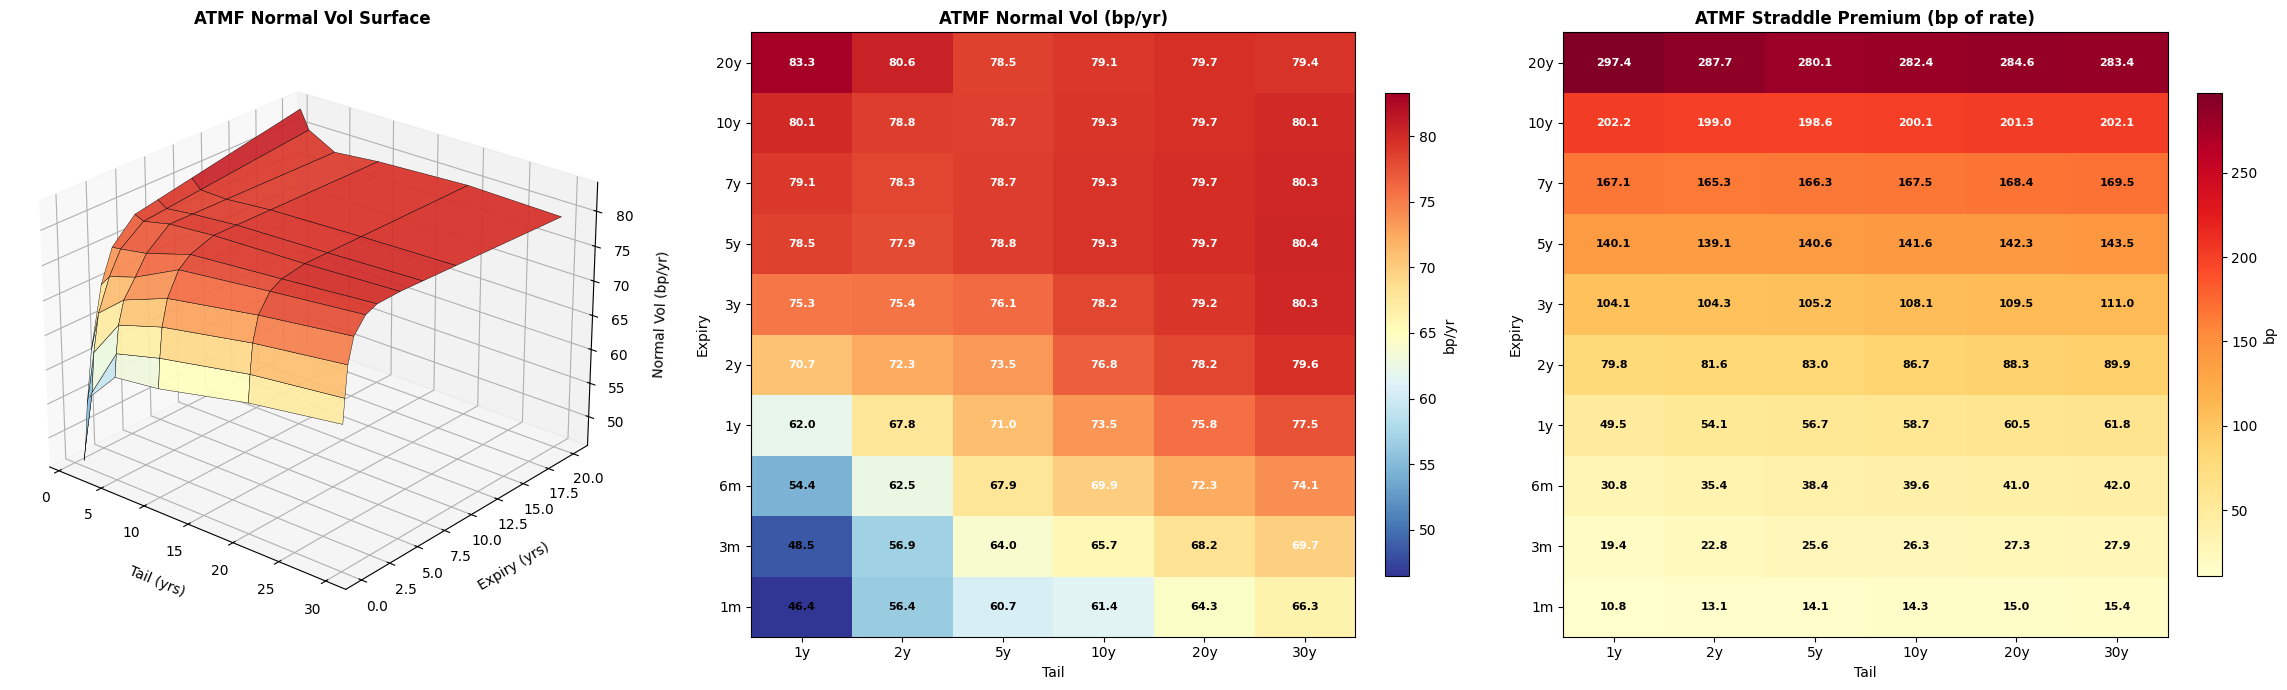

array([[ 10.79788334,  13.11316048,  14.10907612,  14.28719224,
         14.95361629,  15.41285827],
       [ 19.41643628,  22.80452854,  25.6185919 ,  26.30398157,
         27.30783107,  27.92752588],
       [ 30.81835289,  35.41382868,  38.44802103,  39.59292445,
         40.96612899,  41.95297795],
       [ 49.4776195 ,  54.11013726,  56.68491074,  58.67403695,
         60.45172375,  61.84562808],
       [ 79.79715523,  81.60944382,  83.00620455,  86.6827227 ,
         88.3470924 ,  89.87144718],
       [104.05642249, 104.31497019, 105.2440824 , 108.05354082,
        109.46241786, 110.98605132],
       [140.10190299, 139.08260874, 140.64100258, 141.60674267,
        142.32256848, 143.49716526],
       [167.10847354, 165.29592032, 166.29742822, 167.46271126,
        168.36946573, 169.48059331],
       [202.21362609, 198.95700286, 198.64143761, 200.07536187,
        201.26693323, 202.09497325],
       [297.44160188, 287.70831017, 280.14330873, 282.36335972,
        284.55459942, 283.3

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import QuantLib as ql


def plot_atmf_vol_surface(surface: ql.SwaptionVolatilityMatrix):
    """Plot the ATMF normal vol grid as a 3D surface + 2D heatmap.

    Parameters
    ----------
    surface : ql.SwaptionVolatilityMatrix
        Built via _get_atmf_grid().  Must have enableExtrapolation() called.
    """

    EXPIRY_LABELS = ["1m", "3m", "6m", "1y", "2y", "3y", "5y", "7y", "10y", "20y"]
    TAIL_LABELS   = ["1y", "2y", "5y", "10y", "20y", "30y"]

    def _label_to_years(label: str) -> float:
        if label.endswith("m"):
            return int(label[:-1]) / 12.0
        return float(label[:-1])

    def _label_to_ql_period(label: str) -> ql.Period:
        if label.endswith("m"):
            return ql.Period(int(label[:-1]), ql.Months)
        return ql.Period(int(label[:-1]), ql.Years)

    eval_date = surface.referenceDate()
    calendar  = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    dc        = ql.Actual365Fixed()

    expiry_yrs = np.array([_label_to_years(e) for e in EXPIRY_LABELS])
    tail_yrs   = np.array([_label_to_years(t) for t in TAIL_LABELS])

    vol_grid      = np.zeros((len(EXPIRY_LABELS), len(TAIL_LABELS)))
    straddle_grid = np.zeros_like(vol_grid)

    for i, exp_lbl in enumerate(EXPIRY_LABELS):
        exp_date = calendar.advance(eval_date, _label_to_ql_period(exp_lbl))
        T = dc.yearFraction(eval_date, exp_date)
        for j, tail_lbl in enumerate(TAIL_LABELS):
            vol_dec = surface.volatility(exp_date, _label_to_ql_period(tail_lbl), 0.0)
            vol_grid[i, j]      = vol_dec * 10_000.0                        # bpvol
            straddle_grid[i, j] = vol_dec * np.sqrt(2.0 * T / np.pi) * 10_000.0  # bp


    fig, axes = plt.subplots(1, 3, figsize=(24, 7), facecolor="white")

    # --- 3D surface (vol) ---
    ax3d = fig.add_subplot(131, projection="3d")
    axes[0].set_visible(False)  # hide the 2D axes placeholder
    X, Y = np.meshgrid(tail_yrs, expiry_yrs)
    norm_vol = Normalize(vmin=vol_grid.min(), vmax=vol_grid.max())
    ax3d.plot_surface(X, Y, vol_grid, cmap=cm.RdYlBu_r, norm=norm_vol,
                      edgecolor="k", linewidth=0.3, alpha=0.92, rstride=1, cstride=1)
    ax3d.set_xlabel("Tail (yrs)", fontsize=10, labelpad=10)
    ax3d.set_ylabel("Expiry (yrs)", fontsize=10, labelpad=10)
    ax3d.set_zlabel("Normal Vol (bp/yr)", fontsize=10, labelpad=8)
    ax3d.set_title("ATMF Normal Vol Surface", fontsize=12, fontweight="bold")
    ax3d.view_init(elev=25, azim=-50)

    # --- heatmap (vol) ---
    ax_v = axes[1]
    im_v = ax_v.imshow(vol_grid, cmap=cm.RdYlBu_r, aspect="auto", origin="lower")
    ax_v.set_xticks(range(len(TAIL_LABELS)));   ax_v.set_xticklabels(TAIL_LABELS)
    ax_v.set_yticks(range(len(EXPIRY_LABELS))); ax_v.set_yticklabels(EXPIRY_LABELS)
    ax_v.set_xlabel("Tail"); ax_v.set_ylabel("Expiry")
    ax_v.set_title("ATMF Normal Vol (bp/yr)", fontsize=12, fontweight="bold")
    for i in range(len(EXPIRY_LABELS)):
        for j in range(len(TAIL_LABELS)):
            c = "white" if norm_vol(vol_grid[i, j]) > 0.6 else "black"
            ax_v.text(j, i, f"{vol_grid[i,j]:.1f}", ha="center", va="center",
                      fontsize=8, fontweight="bold", color=c)
    fig.colorbar(im_v, ax=ax_v, shrink=0.8, pad=0.04, label="bp/yr")

    # --- heatmap (straddle premium) ---
    ax_s = axes[2]
    norm_str = Normalize(vmin=straddle_grid.min(), vmax=straddle_grid.max())
    im_s = ax_s.imshow(straddle_grid, cmap=cm.YlOrRd, aspect="auto", origin="lower")
    ax_s.set_xticks(range(len(TAIL_LABELS)));   ax_s.set_xticklabels(TAIL_LABELS)
    ax_s.set_yticks(range(len(EXPIRY_LABELS))); ax_s.set_yticklabels(EXPIRY_LABELS)
    ax_s.set_xlabel("Tail"); ax_s.set_ylabel("Expiry")
    ax_s.set_title("ATMF Straddle Premium (bp of rate)", fontsize=12, fontweight="bold")
    for i in range(len(EXPIRY_LABELS)):
        for j in range(len(TAIL_LABELS)):
            c = "white" if norm_str(straddle_grid[i, j]) > 0.6 else "black"
            ax_s.text(j, i, f"{straddle_grid[i,j]:.1f}", ha="center", va="center",
                      fontsize=8, fontweight="bold", color=c)
    fig.colorbar(im_s, ax=ax_s, shrink=0.8, pad=0.04, label="bp")

    plt.tight_layout()
    plt.savefig("atmf_vol_surface.png", dpi=180, bbox_inches="tight")
    plt.show()

    return straddle_grid

as_of = datetime.date(2026, 3, 2)
plot_atmf_vol_surface(get_atmf_grid(curve="GBP-SONIA", dates=[as_of])[as_of])

In [8]:
bc_stirf_curve = BARCHART_STIRF_CURVE()
stirf_mdp = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL")
stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
# stirfo_mdp = STIRFutureOptionMDP(source="STIRFO_DUAL-QL")

In [9]:
out = stirfo_mdp.get_pricer({
    # "endpoint": "option_snapshot",
    "endpoint": "option_snapshot",
    "symbols": ["S0U26|ATMS"],
    "timestamp": datetime.date(2026, 2, 21),
    "show_tqdm": True,
    "use_ql_calculator": True,
})
out

{'S0U26|ATMS': [QLSTIRFutureOptionPricer(_symbol='0QU26|9700S', _right='S', _underlying_symbol='SFRU27', _strike=97.0, _quote_timestamp=datetime.datetime(2026, 2, 20, 17, 0, tzinfo=<DstTzInfo 'America/New_York' EST-1 day, 19:00:00 STD>), _expiry_date=datetime.date(2026, 9, 16), _market_price=0.505, _model_price=0.505000000000002, _iv_normal=0.8484842333942718, _delta=-0.10341477904030966, _gamma=1.2095187379013321, _vega=0.5848190505515247, _theta=-0.41705366726772086, _forward=96.915, _discount=0.9795362204833878, _meta_data={'schema': 1, 'source': 'SYNTH_STRADDLE', 'symbol': '0QU26|9700S', 'underlying_symbol': 'SFRU27', 'legs': ['0QU26|9700C@2026-02-20T17:00:00-05:00', '0QU26|9700P@2026-02-20T17:00:00-05:00'], 'curve_name': 'USD-SOFR-1D-Q12xM12STIRT', 'curve_error': None, 'vendor_legs': [{'Open': 0.22, 'High': 0.22, 'Low': 0.21, 'Close': 0.21, 'Volume': 510.0, 'Open Interest': 77759.0}, {'Open': 0.295, 'High': 0.295, 'Low': 0.295, 'Close': 0.295, 'Volume': 0.0, 'Open Interest': 8839.

In [10]:
p = next(iter(out.values()))[0]
print("price:", p.price())
print("iv_normal_bps:", p.iv_normal_bps())
print("delta/gamma/vega/theta:", p.delta(), p.gamma(), p.vega(), p.theta())

price: 0.505
iv_normal_bps: 84.84842333942719
delta/gamma/vega/theta: -0.10341477904030966 1.2095187379013321 0.5848190505515247 -0.41705366726772086


In [14]:
from MDP.USTFutures.USTFutureOptionMDP import USTFutureOptionMDP

ustfo_mdp = USTFutureOptionMDP(source="BARCHART_USTFO-QL")
out = ustfo_mdp.get_pricer({
    "endpoint": "option_snapshot",
    "symbols": ["TYM26|ATMC"],  
    "timestamp": datetime.date(2026, 3, 4),
    "show_tqdm": True,
    "use_ql_calculator": True,
	# "force_refresh": True
})

pr = next(iter(out.values()))[0]
print("resolved_symbol:", pr.symbol())
print("price:", pr.price(), "iv_normal_bps:", pr.iv_normal_bps())
print("delta:", pr.delta(), "gamma:", pr.gamma(), "vega:", pr.vega(), "theta:", pr.theta())

resolved_symbol: ZNM26|1130C
price: 0.84375 iv_normal_bps: 74.97716751558175
delta: 0.46458249873337554 gamma: 0.16719047540633314 vega: 0.18353330351422634 theta: -2.1190651739995907


SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.04609783611116788, `time`: 0.0210s


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x1fdee609810>])

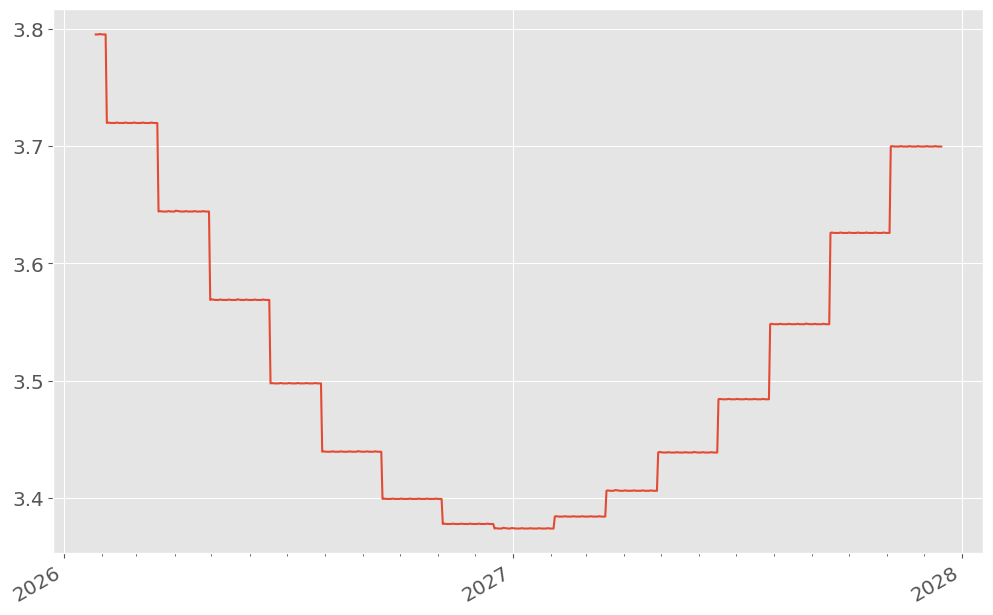

In [4]:
# ts = NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-OIS-Q8xM12", timestamp=ts, kwargs=dict(force_refresh=False))
# curve, solver = bc_stirf_curve.build_curve(curve_name="USD-SOFR-1D-Q12x3", timestamp=ts, kwargs=dict(force_refresh=True))

# timestamps = ql_cal_date_range(
#     ql.UnitedStates(ql.UnitedStates.GovernmentBond),
#     start=NY_tz.localize(datetime.datetime(2026, 2, 17, 1, 50)),
#     end=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
#     freq="1min",
# )
# timestamps = pd.date_range(NY_tz.localize(datetime.datetime(2026, 2, 17, 16, 50)), NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)), freq="1min").to_list()

curves = bc_stirf_curve.build_curve(
    # curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
    curve_name="GBP-SONIA-Q12STIRT",
    timestamp=LDN_tz.localize(datetime.datetime(2026, 1, 27, 17, 00)),
    # timestamp=NY_tz.localize(datetime.datetime(2026, 1, 27, 7, 29)),
    # timestamp="live",
    # kwargs={
    #     "force_refresh": True,
    #     "cache_full_intraday_fetch": True,
    # },
)
curves.plot("1d")

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.03772044499941412, `time`: 0.0201s
SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.009993047585139955, `time`: 0.0195s


(<Figure size 1200x800 with 1 Axes>,
 <Axes: >,
  <matplotlib.lines.Line2D at 0x2880f48efd0>])

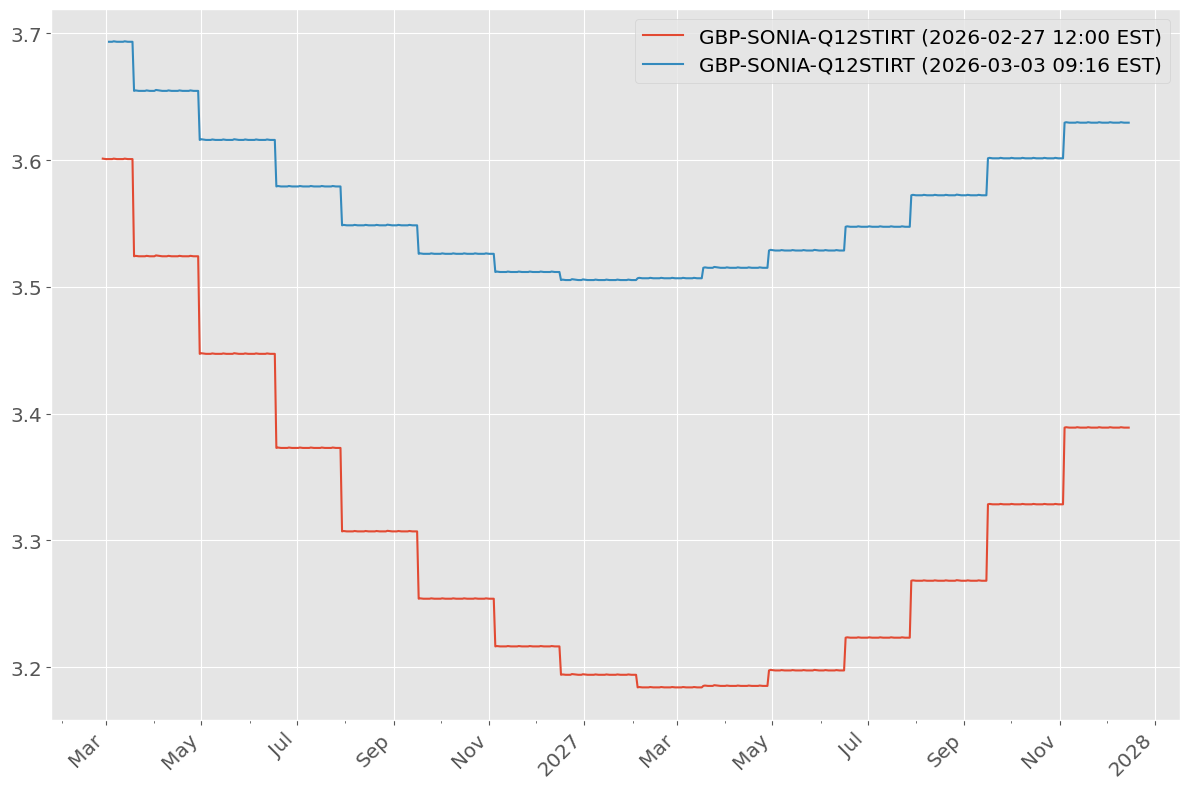

In [4]:
plot_overnight_forward_curves(
    curves=[
        # bc_stirf_curve.build_curve(
        #     curve_name="USD-SOFR-1D-Q12xM12STIRT",
        #     timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
        #     # timestamp="live",
        #     # kwargs={
		# 	# 	"force_refresh": True,
		# 	#     "cache_full_intraday_fetch": True,
        #     # },
        # ),
        # bc_stirf_curve.build_curve(
        #     curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
        #     timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
        # ),
        # bc_stirf_curve.build_curve(
            # curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
        #     timestamp=NY_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
		# 	# kwargs={
		# 	# 	"force_refresh": True,
		# 	# },
        # ),
        bc_stirf_curve.build_curve(
            # curve_name="USD-OIS-Q12xM12STIRT",
            # curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
            curve_name="GBP-SONIA-Q12STIRT",
            timestamp=LDN_tz.localize(datetime.datetime(2026, 2, 27, 17, 00)),
        ),
        bc_stirf_curve.build_curve(
            # curve_name="USD-OIS-Q12xM11STIRT",
            # curve_name="USD-OIS-Q12xM12STIRT-SERFFX-MIX23",
            curve_name="GBP-SONIA-Q12STIRT",
            # timestamp=NY_tz.localize(datetime.datetime(2026, 3, 1, 8, 29)),
            timestamp="live",
        ),
    ]
)

In [110]:
fomc_dated_ois = {
    "mar26": (rl.dt(2026, 3, 18), rl.dt(2026, 4, 29)),
    "apr26": (rl.dt(2026, 4, 29), rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 10, 28)),
    "oct26": (rl.dt(2026, 10, 28), rl.dt(2026, 12, 9)),
    # "dec26": (rl.dt(2026, 12, 9), rl.dt(2027, 1, 27)),
}

ecb_dated_ois = {
    "mar26": (rl.dt(2026, 3, 25), rl.dt(2026, 5, 6)),
    "may26": (rl.dt(2026, 5, 6),  rl.dt(2026, 6, 17)),
    "jun26": (rl.dt(2026, 6, 17), rl.dt(2026, 7, 29)),
    "jul26": (rl.dt(2026, 7, 29), rl.dt(2026, 9, 16)),
    "sep26": (rl.dt(2026, 9, 16), rl.dt(2026, 11, 4)),
    "nov26": (rl.dt(2026, 11, 4), rl.dt(2026, 12, 23)),
}


def build_meeting_dated_ois(meeting: str, meeting_dates: dict, rl_curve: rl.Curve, risk=None, notional=None, rl_irs_swap_kargs={}):
    assert risk is not None or notional is not None, "Must pass in `risk` or `notional`"

    if risk is not None:
        unit_delta = rl.IRS(
            effective=meeting_dates[meeting][0], termination=meeting_dates[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=1
        ).analytic_delta(rl_curve)
        notional = risk / unit_delta

    fomc_swap = rl.IRS(
        effective=meeting_dates[meeting][0], termination=meeting_dates[meeting][1], spec="usd_irs_lt_2y", curves=rl_curve, notional=notional, **rl_irs_swap_kargs
    )
    return fomc_swap



meeting_dates = fomc_dated_ois
for key in meeting_dates.keys():
    print(key, build_meeting_dated_ois(meeting=key, meeting_dates=meeting_dates, rl_curve=curves, notional=1).rate().real)

# for key in ecb_dated_ois.keys():
#     print(key, build_ecb_ois(meeting=key, rl_curve=curves, notional=1).rate().real)

mar26 3.642749968539606
apr26 3.5951974838899146
jun26 3.511426176876371
jul26 3.3988648325850006
sep26 3.274920812397474
oct26 3.1876942095956378


In [123]:
mdp = STIRFutureMDP(source="BARCHART_STIRF-RL")

# must be timezone-aware
chi_tz = pytz.timezone("America/Chicago")
ts = chi_tz.localize(datetime.datetime(2026, 2, 20, 17, 00))

mdp.get_data(
    {
        "symbols": ["SERCM1"],
        # "timestamp": ts,
        "timestamp": "live",
        # "force_refresh": True,
        # "cache_full_intraday_fetch": True,
    }
)

FETCHING SESSION TOKENS...: 100%|██████████| 2/2 [00:00<00:00,  2.00it/s]


{'SERCM1': [RLSTIRFuturePricer(_curve='USD-SOFR-1D', _rl_stirf_id='SR1G26', _reference_date=datetime.date(2026, 2, 27), _effective_date=datetime.date(2026, 2, 2), _maturity_date=datetime.date(2026, 3, 2), _price=96.335, _rate=3.6650000000000063, _contracts=1, _notional=1000000, _meta_data={'symbol': 'SR1G26', 'price': 96.335, 'timestamp': '2026-02-27T15:00:57.593990+00:00', 'schema': 1, 'fixings': USD-SOFR-1D
  2018-04-02    1.80
  2018-04-03    1.83
  2018-04-04    1.74
  2018-04-05    1.75
  2018-04-06    1.75
                ... 
  2026-02-20    3.66
  2026-02-23    3.66
  2026-02-24    3.67
  2026-02-25    3.67
  2026-02-26    3.67
  Name: Fixing, Length: 1974, dtype: float64})]}

In [32]:
bcf = BarchartFetcher()

# USD/CAD FX Forward Tickers

dollar_cad_on_fwd = "USDCAD.O"        # Overnight
dollar_cad_tom_fwd = "USDCAD.A"       # Tomorrow
dollar_cad_spot_fwd = "USDCAD.S"      # Spot
dollar_cad_1w_fwd = "USDCAD.B"        # 1-Week
dollar_cad_2w_fwd = "USDCAD.C"        # 2-Week
dollar_cad_3w_fwd = "USDCAD.D"        # 3-Week
dollar_cad_1m_fwd = "USDCAD.E"        # 1-Month
dollar_cad_2m_fwd = "USDCAD.G"        # 2-Month
dollar_cad_3m_fwd = "USDCAD.H"        # 3-Month
dollar_cad_4m_fwd = "USDCAD.J"        # 4-Month
dollar_cad_5m_fwd = "USDCAD.K"        # 5-Month
dollar_cad_6m_fwd = "USDCAD.M"        # 6-Month
dollar_cad_7m_fwd = "USDCAD.N"        # 7-Month
dollar_cad_8m_fwd = "USDCAD.Q"        # 8-Month
dollar_cad_9m_fwd = "USDCAD.U"        # 9-Month
dollar_cad_10m_fwd = "USDCAD.V"       # 10-Month
dollar_cad_11m_fwd = "USDCAD.X"       # 11-Month
dollar_cad_1y_fwd = "USDCAD.1"        # 1-Year
dollar_cad_2y_fwd = "USDCAD.2"        # 2-Year
dollar_cad_3y_fwd = "USDCAD.3"        # 3-Year


df = bcf.barchart_timeseries_api(
    barchart_symbols=[dollar_cad_1w_fwd],
    start_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 7, 00)),
    end_date=NY_tz.localize(datetime.datetime(2026, 2, 17, 17, 00)),
    interval=1,
)[dollar_cad_1w_fwd]

df

FETCHING INTRADAY DATA FROM BARCHART...: 100%|██████████| 1/1 [00:00<00:00,  2.18it/s]


,Open,High,Low,Close,Volume
Date,,,,,
2026-02-17 07:00:00-05:00,-3.9925,-3.9925,-3.9925,-3.9925,0
2026-02-17 07:01:00-05:00,-3.9925,-3.9925,-3.9925,-3.9925,0
2026-02-17 07:02:00-05:00,-3.9925,-3.9925,-3.9930,-3.9930,0
2026-02-17 07:03:00-05:00,-3.9930,-3.9930,-3.9930,-3.9930,0
2026-02-17 07:04:00-05:00,-3.9930,-3.9930,-3.9930,-3.9930,0
...,...,...,...,...,...
2026-02-17 16:46:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0
2026-02-17 16:47:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0
2026-02-17 16:48:00-05:00,-3.9940,-3.9940,-3.9940,-3.9940,0


SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.0077315050425418, `time`: 0.1431s
SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.007916590264343258, `time`: 0.0239s


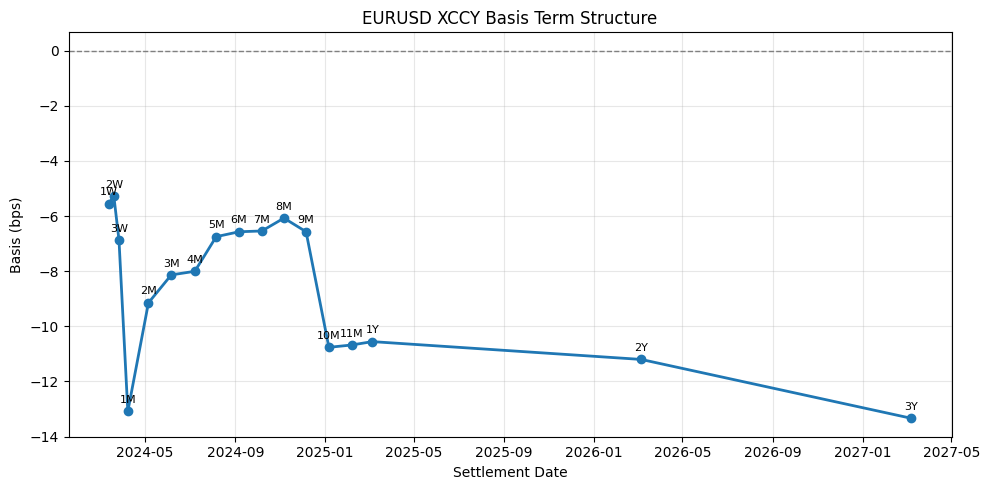

,tenor,settlement_date,basis_bps
3,1W,2024-03-13,-5.553668
4,2W,2024-03-20,-5.270464
5,3W,2024-03-27,-6.870113
6,1M,2024-04-08,-13.085823
7,2M,2024-05-06,-9.147268
8,3M,2024-06-06,-8.134355
9,4M,2024-07-08,-8.003425
10,5M,2024-08-06,-6.747418
11,6M,2024-09-06,-6.569144
12,7M,2024-10-07,-6.540329


In [17]:
from MDP.STIRFutures.FXForwardMDP import FXForwardMDP

mdp = FXForwardMDP(source="BARCHART_FXFWD-RL")

req = {
    "symbols": ["EURUSD"],  # full O..3Y strip
    "timestamp": LDN_tz.localize(datetime.datetime(2024, 3, 4, 17, 00)),  
    "curve_profile_key": "eurusd_sofr_estr_ldn",  
    "force_refresh": False,
    "window_minutes": 1,
}
out = mdp.get_data(req)

strip = next(iter(out.values())) 

rows = []
for p in strip:
    rows.append(
        {
            "tenor": p.tenor(),
            "symbol": p.symbol(),
            "settlement_date": p.settlement_date(),
            "basis_bps": p.basis_bps(),
        }
    )

df = pd.DataFrame(rows).sort_values("settlement_date")

# keep only calibrated tenors (O/A/S are typically None by design)
basis_df = df.dropna(subset=["basis_bps"]).copy()

if basis_df.empty:
    raise RuntimeError(f"No basis points available. curve_error={strip[0].meta().get('curve_error')}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(basis_df["settlement_date"], basis_df["basis_bps"], marker="o", lw=2)
ax.axhline(0.0, color="gray", lw=1, ls="--")
ax.set_title(f"{next(iter(out.keys()))} XCCY Basis Term Structure")
ax.set_xlabel("Settlement Date")
ax.set_ylabel("Basis (bps)")
ax.grid(alpha=0.3)

# optional: annotate tenor labels
for _, r in basis_df.iterrows():
    ax.annotate(r["tenor"], (r["settlement_date"], r["basis_bps"]), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)

plt.tight_layout()
plt.show()

basis_df[["tenor", "settlement_date", "basis_bps"]]

In [34]:
out

{'EURUSD': [RLFXForwardPricer(_pair='EURUSD', _symbol='EURUSD.O', _tenor='ON', _settlement_date=datetime.date(2026, 2, 18), _quote_timestamp=datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc), _spot=1.18296, _points_raw=0.58, _points_decimal=5.7999999999999994e-05, _forward_rate=1.183018, _basis_bps=None, _fx_rates=<rl.FXRates:[eur,usd] at 0x295c16bacf0>, _fx_forwards=<rl.FXForwards:[eur,usd] at 0x295c16ba900>, _meta_data={'schema': 1, 'source': 'BARCHART_FXFWD-RL', 'symbol': 'EURUSD.O', 'pair': 'EURUSD', 'suffix': 'O', 'tenor': 'ON', 'spot_symbol': '^EURUSD', 'spot_lag_bdays': 2, 'settlement_calendar': 'nyc,tgt', 'curve_profile_key': 'eurusd_sofr_estr_ldn', 'curve_names': {'EUR': 'EUR-ESTR-LONDON-Q12STIRT', 'USD': 'USD-SOFR-1D-Q12xM12STIRT'}, 'curve_error': None, 'spot_timestamp': datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc), 'quote_timestamp': datetime.datetime(2026, 2, 17, 17, 0, tzinfo=datetime.timezone.utc)}),
  RLFXForwardPricer(_pair='EURU